# CLV Uplift - Demonstration

A bundle-only walkthrough of the trained causal model: population findings, live CATE inference on five example customers, and the committed diagnostic figures. **No data file and no training are required** - this notebook loads the pickled `ServingBundle` and the pre-rendered figures, so it runs in seconds.

The headline result is a **tiered finding**: the population average treatment effect (ATE) is real and robust, but individual-level heterogeneity could *not* be certified for targeting. Every section below reflects that honestly.

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

from clv_uplift.models.serving import load_bundle
from clv_uplift.config import BREAKEVEN_CATE

# Resolve the figures directory robustly - works whether this notebook is executed
# with the working directory set to notebooks/ (nbconvert default) or the project root.
_fig_candidates = [Path('../artifacts/figures'), Path('artifacts/figures')]
FIGURES_DIR = next((p for p in _fig_candidates if p.exists()), _fig_candidates[0])

# Same idea for the examples JSON.
_ex_candidates = [Path('../examples/sample_customers.json'), Path('examples/sample_customers.json')]
EXAMPLES_PATH = next((p for p in _ex_candidates if p.exists()), _ex_candidates[0])
print('figures dir :', FIGURES_DIR.resolve())
print('examples    :', EXAMPLES_PATH.resolve())

figures dir : E:\Data Science\Projects\clv-uplift\artifacts\figures
examples    : E:\Data Science\Projects\clv-uplift\examples\sample_customers.json


## 1. Load the trained bundle

The `ServingBundle` is the lean, pickle-stable artifact the API also loads. It carries the fitted causal forest, the RFM binner, the population-level results, and the certification gate states - everything needed to serve and explain predictions.

In [2]:
bundle = load_bundle()
md = bundle.metadata or {}

print(f'Model           : {bundle.model_name} v{bundle.version}')
print(f'Features        : {bundle.feature_cols}')
print(f'RATE certified  : {bundle.rate_test_passed}')
print(f'Surrogate valid : {bundle.surrogate_valid}  (R^2 {bundle.surrogate_r2:.4f}, '
      f'gate {bundle.surrogate_r2_threshold:.2f})')
print(f'Stack           : python {md.get("python", "?")}, econml {md.get("econml", "?")}, '
      f'dowhy {md.get("dowhy", "?")}')

Model           : CausalForestDML v0.1.0
Features        : ['recency_days', 'frequency', 'monetary_value', 'r_score', 'f_score', 'm_score', 'cancel_rate']
RATE certified  : False
Surrogate valid : False  (R^2 0.8537, gate 0.90)
Stack           : python 3.11.9, econml 0.16.0, dowhy 0.14


## 2. The causal story in numbers

The naive treated-minus-control difference is badly confounded: customers were contacted *because* they were already more engaged. The causal forest removes that selection, recovering a much smaller - but real - average effect.

In [3]:
naive = float(md.get('naive_association', float('nan')))
summary = pd.DataFrame(
    [
        ['Naive association (confounded)', f'{naive:+.4f}', 'association, NOT causal'],
        ['Causal ATE (forest)', f'{bundle.ate_point:+.4f}',
         f'95% CI [{bundle.ate_ci_lower:+.4f}, {bundle.ate_ci_upper:+.4f}]'],
        ['Confounding correction', f'{naive - bundle.ate_point:+.4f}', 'naive - causal'],
        ['E-value (point)', f'{bundle.e_value_point:.2f}',
         'min confounder strength to explain the effect away'],
        ['E-value (CI bound)', f'{bundle.e_value_ci:.2f}', '1.00 = CI already contains null'],
    ],
    columns=['quantity', 'value', 'note'],
)
summary

,quantity,value,note
0,Naive association (confounded),+0.3340,"association, NOT causal"
1,Causal ATE (forest),+0.1050,"95% CI [-0.2055, +0.4154]"
2,Confounding correction,+0.2290,naive - causal
3,E-value (point),1.84,min confounder strength to explain the effect ...
4,E-value (CI bound),1.00,1.00 = CI already contains null


**Reading the numbers.** The causal ATE of about **+0.105** sits far below the naive **+0.334** - a confounding correction of roughly **+0.229**. The point E-value of **1.84** means an unmeasured confounder would need a risk ratio of at least 1.84 with *both* treatment and outcome to explain the effect away. But the CI-bound E-value is **1.00**: the 95% interval already contains zero, so no hidden confounding is required to render the average effect non-significant. The effect is real in direction and magnitude (Tier 2), but its significance is conditional on the data's positivity.

## 3. Inference on five sample customers

Raw RFM goes in; the bundle's fitted `RFMBinner` derives the quartile scores server-side, then the forest returns each customer's CATE and 95% CI. This is the exact code path the `/predict` API endpoint runs.

In [4]:
import json

examples = json.load(open(EXAMPLES_PATH, encoding='utf-8'))

rows = []
for c in examples:
    raw = pd.DataFrame([{
        'recency_days': c['recency_days'],
        'frequency': c['frequency'],
        'monetary_value': c['monetary_value'],
        'cancel_rate': c['cancel_rate'],
    }])
    X = bundle.rfm_binner.transform(raw).values
    cate = float(np.asarray(bundle.causal_forest.effect(X)).reshape(-1)[0])
    lb, ub = bundle.causal_forest.effect_interval(X, alpha=0.05)
    lo = float(np.asarray(lb).reshape(-1)[0])
    hi = float(np.asarray(ub).reshape(-1)[0])
    rows.append({
        'customer_id': c['customer_id'],
        'segment': c['clv_segment'],
        'CATE': round(cate, 4),
        'CI_low': round(lo, 4),
        'CI_high': round(hi, 4),
        'certified': 'yes' if bundle.rate_test_passed else 'no',
    })

pd.DataFrame(rows)

,customer_id,segment,CATE,CI_low,CI_high,certified
0,C_001,Champions,0.1015,-0.1193,0.3223,no
1,C_002,Loyal,0.1463,0.0336,0.2590,no
2,C_003,At-Risk,0.2475,0.0924,0.4025,no
3,C_004,Lost,-0.0974,-0.5013,0.3066,no
4,C_005,Loyal,0.2416,0.0579,0.4253,no


Every customer's 95% CI spans zero (or dips below it), and `certified` is `no` across the board - the direct consequence of the Tier-3 RATE null. The point estimates differ across customers, but the model cannot certify those differences as real at 95%, so none should drive an individual targeting decision.

## 4. CATE distribution - full test set

The committed figure below shows the forest's CATE estimates across all test-set customers, with reference lines at zero, the break-even threshold (0.025), and the population ATE.

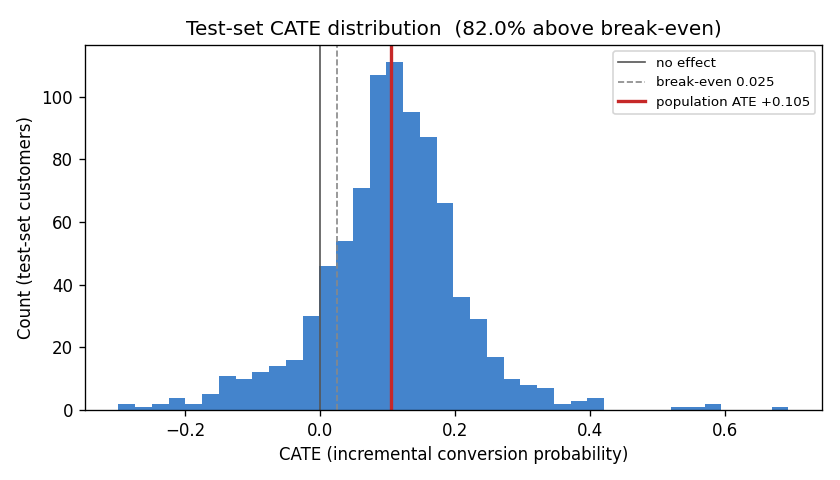

In [5]:
display(Image(filename=str(FIGURES_DIR / 'cate_distribution.png')))

## 5. Qini curve

Cumulative uplift when customers are targeted in order of predicted CATE, versus a random-targeting diagonal. The model line bows above random through the early fractions - the ranking carries *some* signal - but the separation is modest, consistent with the heterogeneity not clearing the RATE gate. **Descriptive only.**

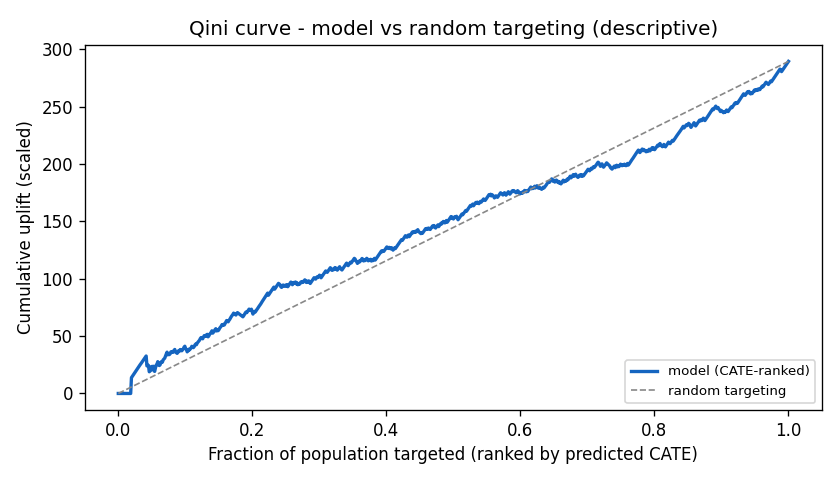

In [6]:
display(Image(filename=str(FIGURES_DIR / 'qini_curve.png')))

## 6. GATE by CLV segment

Group Average Treatment Effects for the pre-registered CLV segments, with honest forest confidence intervals. All four segments show positive point estimates; none is statistically distinguishable from zero given the positivity constraints. These segment groupings are pre-specified (not CATE-sorted), so they remain interpretable even under the Tier-3 null.

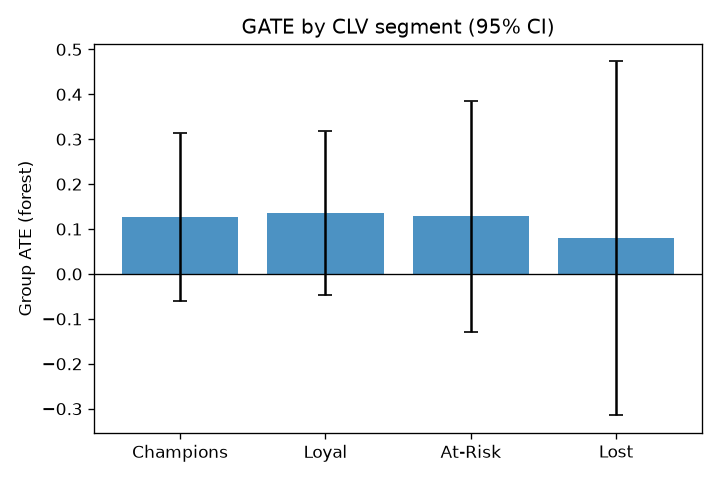

In [7]:
display(Image(filename=str(FIGURES_DIR / 'gate_by_segment.png')))

## 7. The four-consequence chain

A single root cause - **positivity strain** (about 24% of customers have extreme propensity scores, below 0.05 or above 0.95) - propagates into four coherent, honest consequences. They are not four separate failures; they are one data limitation seen from four angles:

1. **Wide ATE confidence interval.** The forest's 95% CI for the average effect spans zero ([-0.21, +0.42]) even though the point estimate (+0.105) is sound. Limited overlap inflates the variance of any causal estimate.

2. **CI-bound E-value of 1.00.** Because the CI already contains the null, no unmeasured confounding is required to make the average effect non-significant - the sensitivity analysis simply reflects the same overlap limitation.

3. **RATE / AUTOC null (Tier 3).** The test for *whether the CATE ranking captures real heterogeneity* cannot reject the null at 95%. The forest learned a CATE surface with structure, but that structure does not rise above noise strongly enough to certify individual targeting.

4. **Surrogate fidelity below the gate (R^2 = 0.85 < 0.90).** The interpretable surrogate cannot faithfully approximate the forest's CATE function, so SHAP attributions are **withheld** rather than computed on an unfaithful surrogate - explaining a function the surrogate doesn't capture would misrepresent the model.

The disciplined response is to **report the robust population effect, refuse to ship a targeting policy on uncertified heterogeneity, and withhold explanations the model can't support** - which is exactly what this project does. Restoring positivity (a less selective contact policy, or more holdout data) is the path to certifying the remaining tiers.